In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [4]:
sales = pd.read_csv("D:/Data Analysis/Tamweely Train/Brazilian E-Commerce Dataset/data/Sales_Master_Clean.csv")

sales.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,City,State,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,Revenue,freight_value,payment_sequential,payment_type,payment_installments,Payment,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,Delivery_Days,Order_Month,Order_Year,quantity,Total_Revenue,Profit,Delivery_Status,Customer_Type
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,1,credit_card,2,146.87,moveis escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,8.0,5,2017,1,146.87,29.374,Delayed,New
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,1,credit_card,8,335.48,utilidades domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,16.0,1,2018,1,335.48,67.096,Delayed,New
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,1,credit_card,7,157.73,moveis escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,26.0,5,2018,1,157.73,31.546,Delayed,New
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,1,credit_card,1,173.30,moveis escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,14.0,3,2018,1,173.30,34.660,Delayed,New
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,1,credit_card,8,252.25,casa conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,11.0,7,2018,1,252.25,50.450,Delayed,New


In [5]:
print(sales.columns.tolist())

['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'City', 'State', 'order_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'Revenue', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'Payment', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'Delivery_Days', 'Order_Month', 'Order_Year', 'quantity', 'Total_Revenue', 'Profit', 'Delivery_Status', 'Customer_Type']


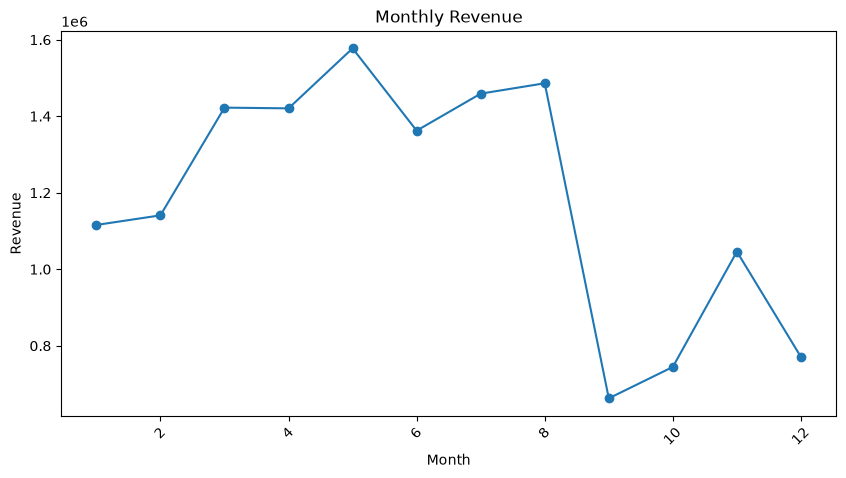

In [6]:
monthly_revenue = (
    sales.groupby("Order_Month")["Revenue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index,
         monthly_revenue.values,
         marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

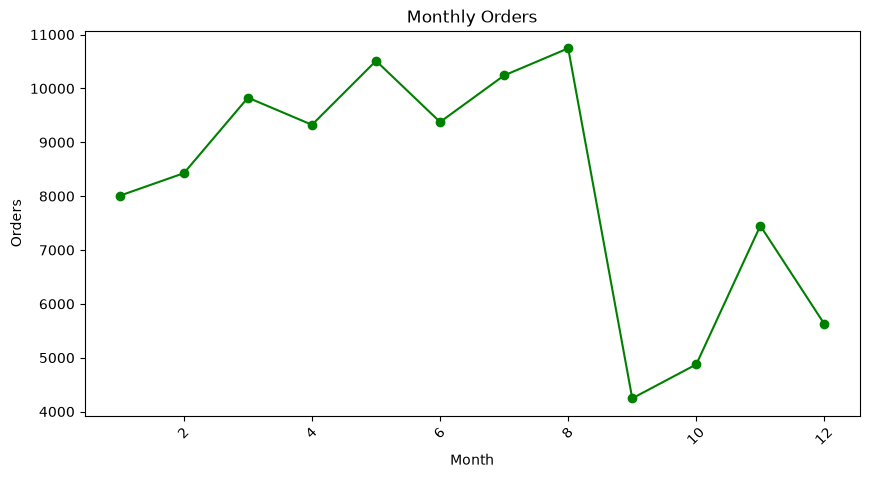

In [7]:
monthly_orders = (
    sales.groupby("Order_Month")["order_id"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_orders.index,
         monthly_orders.values,
         marker="o",
         color="green")

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)
plt.show()

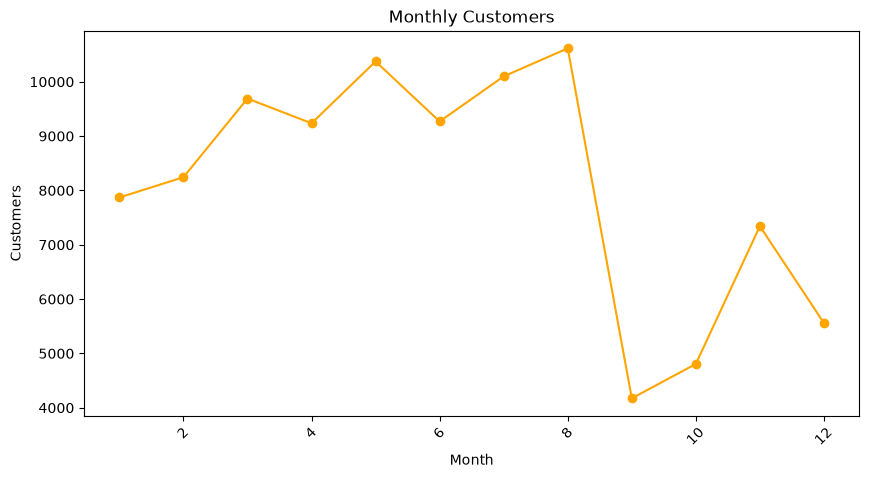

In [8]:
monthly_customers = (
    sales.groupby("Order_Month")["customer_unique_id"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_customers.index,
         monthly_customers.values,
         marker="o",
         color="orange")

plt.title("Monthly Customers")
plt.xlabel("Month")
plt.ylabel("Customers")

plt.xticks(rotation=45)
plt.show()

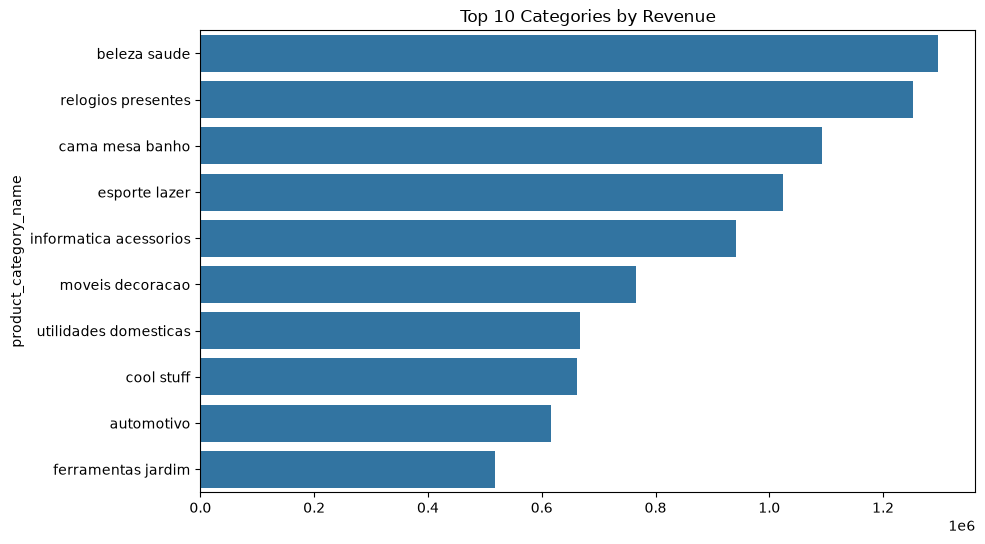

In [12]:
top_categories = (
    sales.groupby("product_category_name")["Revenue"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Categories by Revenue")
plt.show()

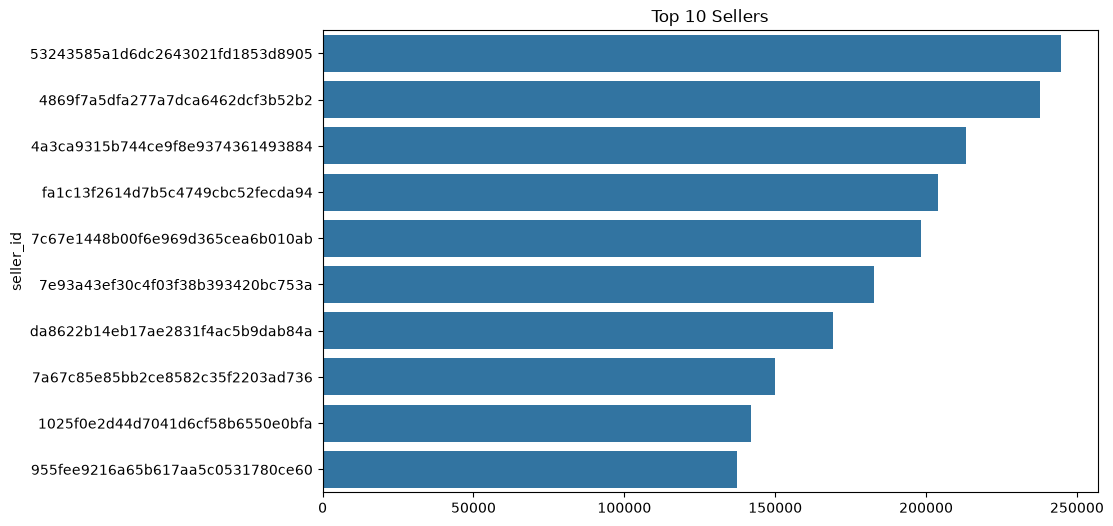

In [13]:
top_sellers = (
    sales.groupby("seller_id")["Revenue"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index
)

plt.title("Top 10 Sellers")
plt.show()

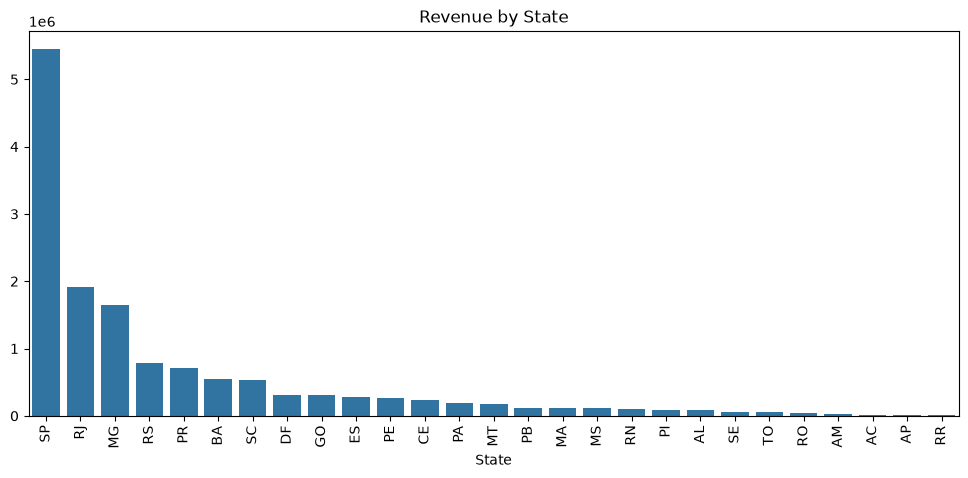

In [16]:
state_rev = (
    sales.groupby("State")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=state_rev.index,
    y=state_rev.values
)

plt.xticks(rotation=90)

plt.title("Revenue by State")

plt.show()

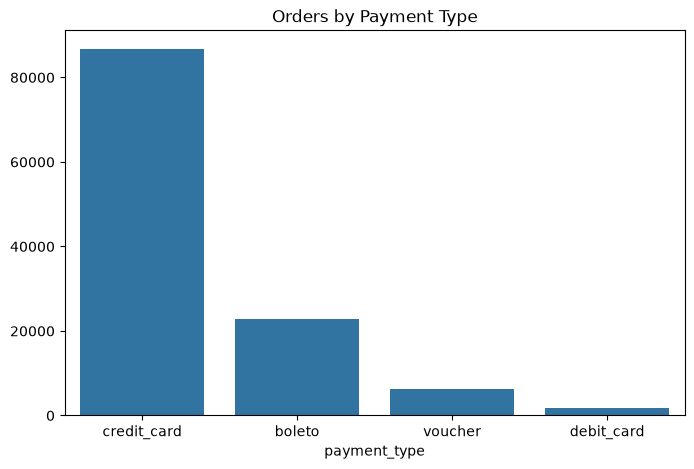

In [17]:
payment = (
    sales["payment_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Orders by Payment Type")

plt.show()

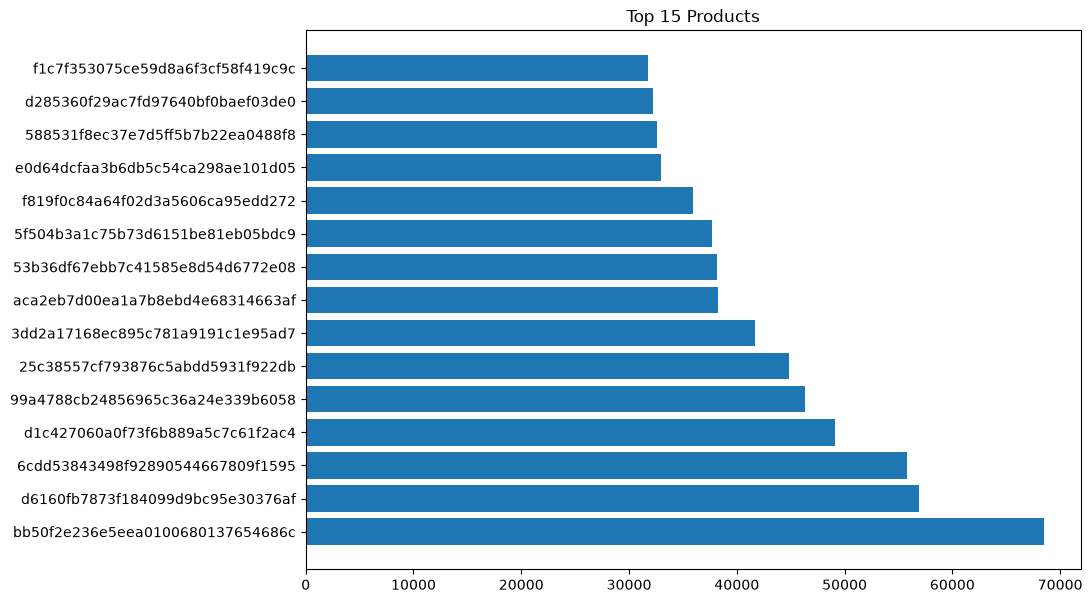

In [18]:
top_products = (
    sales.groupby("product_id")["Revenue"]
    .sum()
    .nlargest(15)
)

plt.figure(figsize=(10,7))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 15 Products")

plt.show()

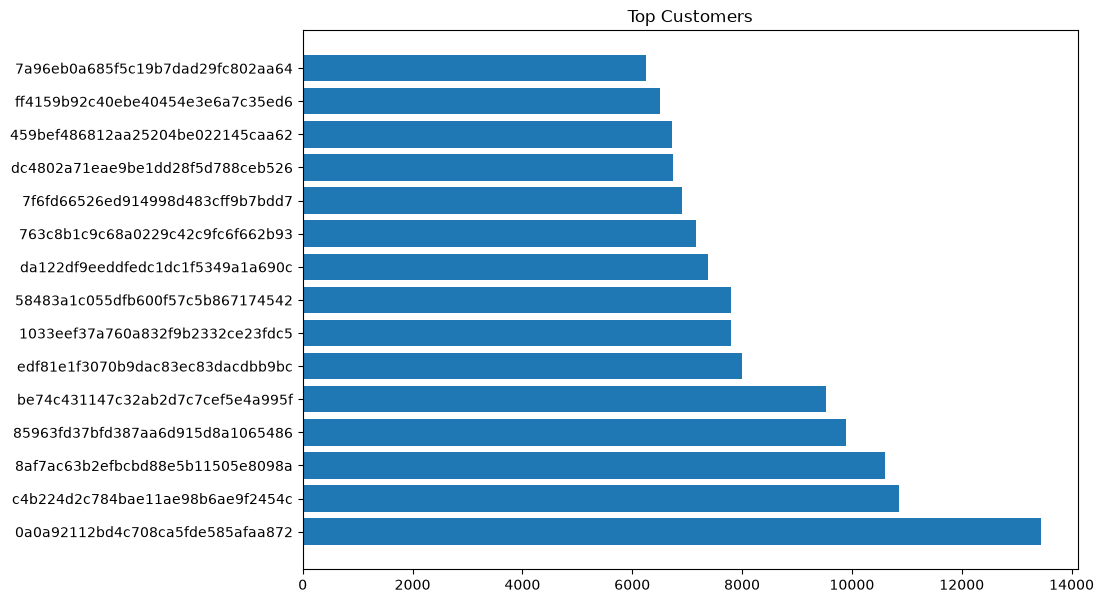

In [19]:
top_customers = (
    sales.groupby("customer_unique_id")["Revenue"]
    .sum()
    .nlargest(15)
)

plt.figure(figsize=(10,7))

plt.barh(
    top_customers.index,
    top_customers.values
)

plt.title("Top Customers")

plt.show()

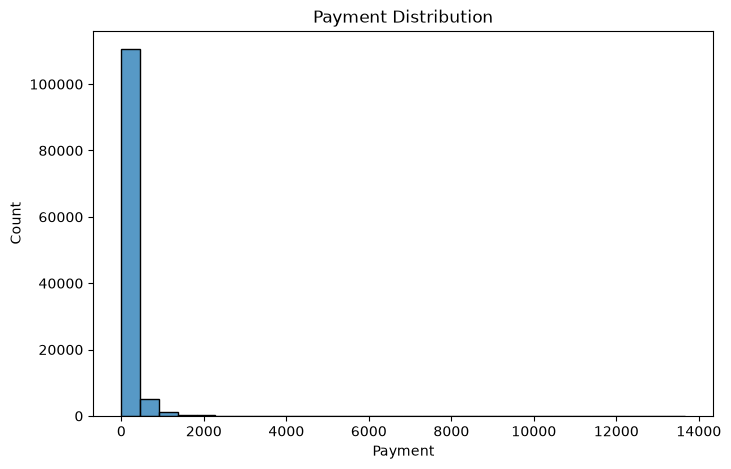

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["Payment"],
    bins=30
)

plt.title("Payment Distribution")

plt.show()

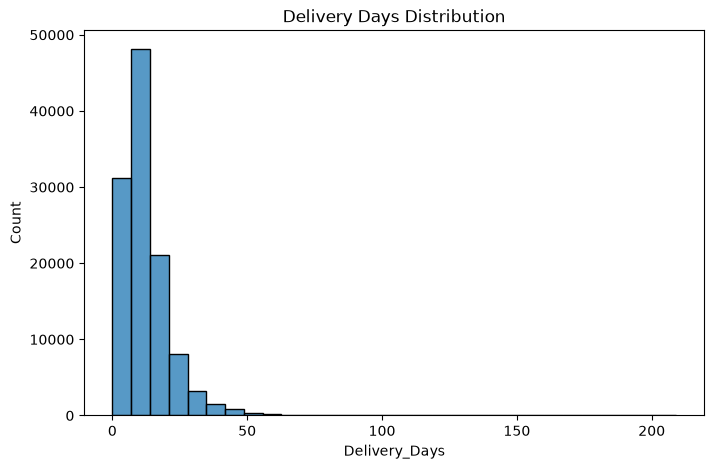

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["Delivery_Days"],
    bins=30
)

plt.title("Delivery Days Distribution")

plt.show()

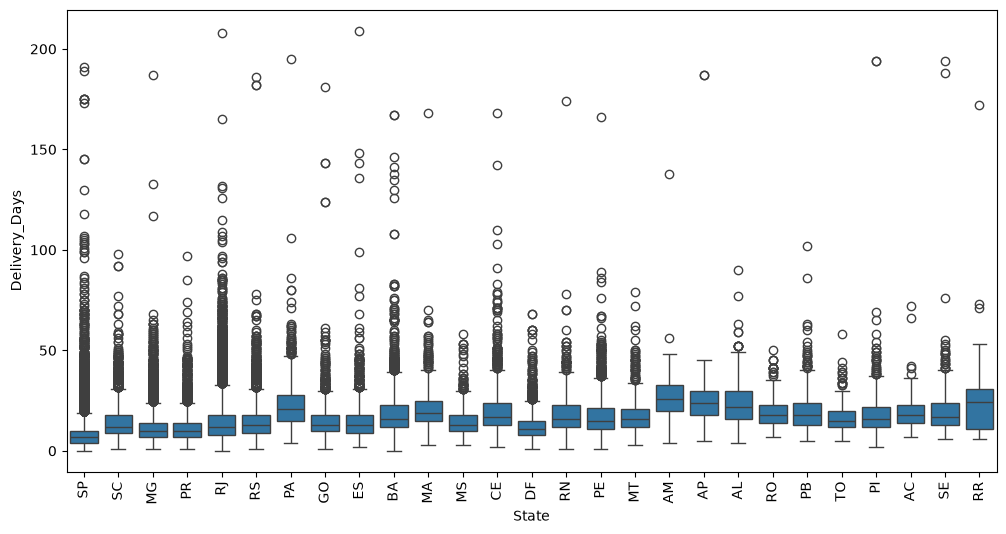

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="State",
    y="Delivery_Days",
    data=sales
)

plt.xticks(rotation=90)

plt.show()

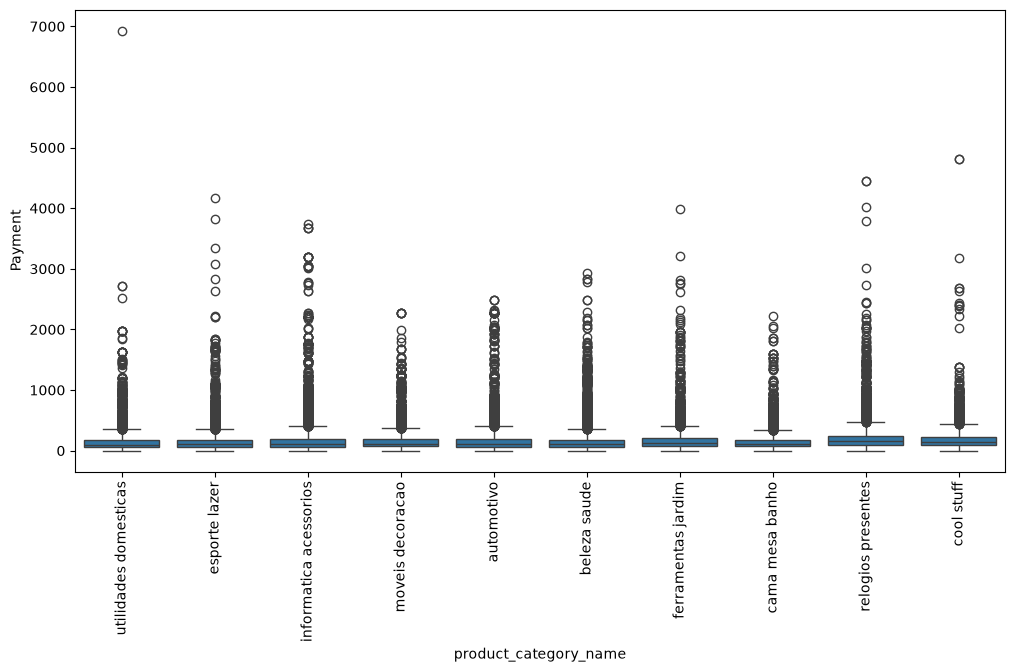

In [27]:
top_cat = (
    sales.groupby("product_category_name")["Revenue"]
    .sum()
    .nlargest(10)
    .index
)

temp = sales[
    sales["product_category_name"].isin(top_cat)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    x="product_category_name",
    y="Payment",
    data=temp
)

plt.xticks(rotation=90)

plt.show()

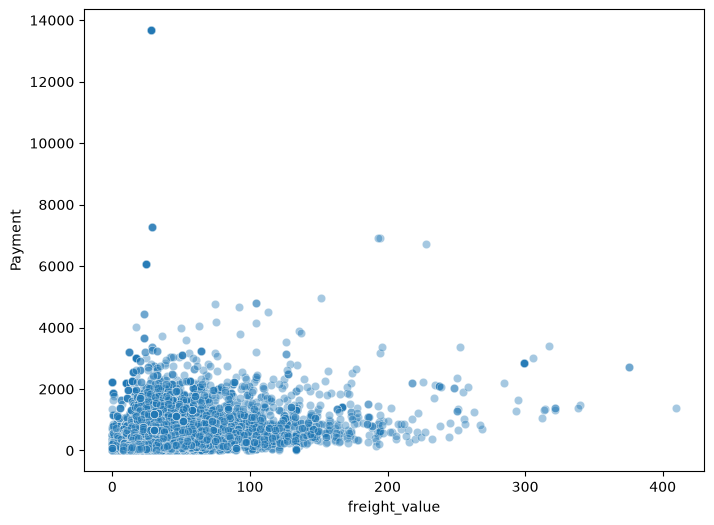

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="freight_value",
    y="Payment",
    data=sales,
    alpha=.4
)

plt.show()

In [29]:
sns.scatterplot(
    x="review_score",
    y="Delivery_Days",
    data=sales
)

ValueError: Could not interpret value `review_score` for `x`. An entry with this name does not appear in `data`.

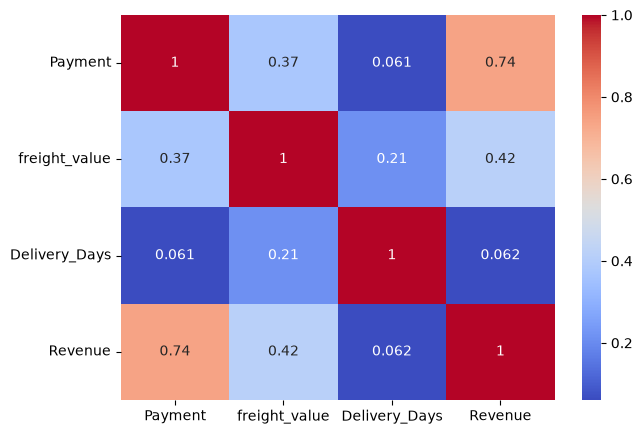

In [31]:
corr = sales[
    [
        "Payment",
        "freight_value",
        "Delivery_Days",
        "Revenue"
    ]
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()